In [54]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv(r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-06-regression-and-classification-ML\datasets\kc_house_data.csv")
print(df.shape)
df.head()

(21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
df = df.drop(columns=['id', 'date'])

In [8]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [12]:
df.corr()['price'].drop('price').sort_values(ascending=False)

sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

In [13]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat', 'waterfront', 'floors']

X = df[features]

print(X.shape)

(21613, 11)


In [14]:
y = df['price']

In [15]:
y.shape

(21613,)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("X train : ", X_train.shape)
print("X test : ", X_test.shape)
print("Y train : ", y_train.shape)
print("Y test : ", y_test.shape)

X train :  (17290, 11)
X test :  (4323, 11)
Y train :  (17290,)
Y test :  (4323,)


In [28]:
model = LinearRegression()


In [29]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
prediction = model.predict(X_test)

In [32]:
prediction.shape

(4323,)

In [55]:
r2_score(y_test, prediction)

0.6614781405487565

In [58]:
np.sqrt(mean_squared_error(y_test, prediction))

226222.50493466976

In [59]:
model.coef_

array([ 1.28659658e+02,  8.00263262e+04,  6.50287415e+01,  3.35505098e+00,
       -5.26090513e+02,  6.85711779e+04,  6.36309160e+01, -2.39310851e+04,
        6.71230692e+05,  5.84624181e+05, -3.05952288e+04])

In [60]:
features

['sqft_living',
 'grade',
 'sqft_above',
 'sqft_living15',
 'bathrooms',
 'view',
 'sqft_basement',
 'bedrooms',
 'lat',
 'waterfront',
 'floors']

In [62]:
model.intercept_

-32299223.004822798

## polynomial regression

In [74]:
x = np.linspace(0, 10, 40)

y_true = 5*x + 0.2*x**2 + 0.1*x**3

y = y_true + np.random.normal(0, 10, len(x))

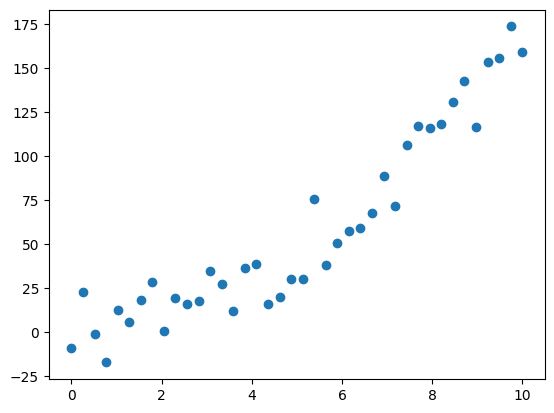

In [75]:
plt.scatter(x, y)

In [76]:
x.shape

(40,)

In [77]:
y.shape

(40,)

In [84]:
x = x.reshape(-1, 1)

In [85]:
model1 = LinearRegression()
model1.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [86]:
pred = model1.predict(x)

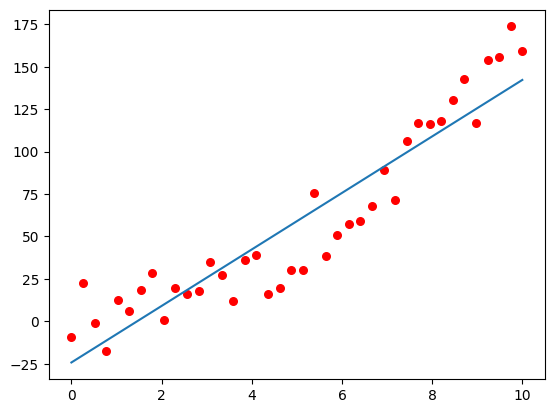

In [87]:
plt.scatter(x,y, color='red', s=30, )
plt.plot(x, pred)

In [88]:
r2_score(pred, y)

0.8412405193187151

In [ ]:
x = np.column_stack([x, *x*2, x**3])

In [95]:
x.shape

(40, 3)

In [97]:
y.shape

(40,)

In [98]:
model2 = LinearRegression()

model2.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [100]:
pred = model2.predict(x)

In [105]:
x[:, 0].shape

(40,)

In [106]:
pred.shape

(40,)

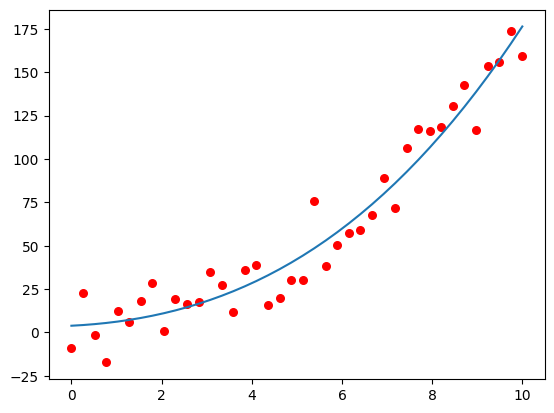

In [107]:
plt.scatter(x[:, 0],y, color='red', s=30, )
plt.plot(x[:, 0], pred)

In [108]:
r2_score(pred, y)

0.940279828758502